In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações de estilo para apresentação
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def load_and_explore(filepath: str) -> pd.DataFrame:
    """
    Carrega o dataset e retorna informações essenciais para o case.
    """
    print("🔍 Carregando dataset...")
    df = pd.read_csv(filepath, encoding='utf-8')
    
    print(f"\n📦 Shape: {df.shape}")
    print(f"\n📋 Colunas: {list(df.columns)}")
    print(f"\n🔎 Tipos de dados:\n{df.dtypes}")
    print(f"\n❌ Missing values:\n{df.isnull().sum()}")
    print(f"\n📊 Primeiras linhas:\n{df.head(3).to_string()}")
    
    return df

# Execução
if __name__ == "__main__":
    df = load_and_explore('articles.csv')
    
    # Conversão de data
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    
    # Métricas rápidas para storytelling
    print(f"\n📈 Período: {df['date'].min().date()} a {df['date'].max().date()}")
    print(f"📰 Total de notícias: {len(df):,}")
    print(f"🏷️  Categorias únicas: {df['category'].nunique()}")
    print(f"📝 Tamanho médio do texto: {df['text'].str.len().mean():.0f} caracteres")

🔍 Carregando dataset...

📦 Shape: (167053, 6)

📋 Colunas: ['title', 'text', 'date', 'category', 'subcategory', 'link']

🔎 Tipos de dados:
title          str
text           str
date           str
category       str
subcategory    str
link           str
dtype: object

❌ Missing values:
title               0
text              765
date                0
category            0
subcategory    137418
link                0
dtype: int64

📊 Primeiras linhas:
                                                                      title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download de recursos NLTK (executar uma vez)
# nltk.download('punkt')
# nltk.download('stopwords')

def clean_text(text: str) -> str:
    """Limpeza básica para análise de texto"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)  # Remove URLs, menções
    text = re.sub(r'[^a-zà-ú\s]', '', text)  # Mantém apenas letras e acentos
    text = re.sub(r'\s+', ' ', text).strip()  # Remove espaços extras
    return text

def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Cria features derivadas para análise"""
    df = df.copy()
    
    # Features temporais
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.day_name()
    df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
    
    # Features de texto
    df['text_clean'] = df['text'].apply(clean_text)
    df['title_length'] = df['title'].str.len()
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text_clean'].apply(lambda x: len(x.split()))
    
    # Feature de categoria (agrupar categorias raras)
    category_counts = df['category'].value_counts()
    rare_categories = category_counts[category_counts < 1000].index
    df['category_grouped'] = df['category'].apply(
        lambda x: 'outros' if x in rare_categories else x
    )
    
    return df

# Execução
if __name__ == "__main__":
    df = pd.read_csv('articles.csv', encoding='utf-8')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    
    df_processed = create_features(df)
    
    print("✅ Features criadas:")
    print(df_processed[['title_length', 'text_length', 'word_count', 
                       'year', 'month', 'category_grouped']].head())
    
    # Salvar para próxima etapa
    df_processed.to_csv('articles_processed.csv', index=False, encoding='utf-8')
    print("💾 Dataset processado salvo!")

✅ Features criadas:
   title_length  text_length  word_count  year  month category_grouped
0            72       2989.0         499  2017      9            poder
1            71       2894.0         485  2017      9        ilustrada
2            63       4078.0         624  2017      9            poder
3            68        851.0         141  2017      9        ilustrada
4            70       4015.0         636  2017      9          mercado
💾 Dataset processado salvo!


new eda visualizations w/ stop words

In [ ]:
# 03_eda_visualizations.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
import nltk
import re
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ CONFIGURAÇÃO DE STOP WORDS (PT-BR + JORNALISMO)
# ==========================================
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

def get_custom_stopwords():
    """Combina stop words padrão do NLTK com termos jornalísticos e ruídos comuns"""
    base_stop = set(nltk.corpus.stopwords.words('portuguese'))
    
    # Termos que aparecem em notícias mas não agregam contexto temático
    journalism_noise = {
        'disse', 'afirmou', 'informou', 'reportou', 'declarou',
        'segundo', 'conforme', 'apontou', 'destacou', 'ressaltou',
        'ontem', 'hoje', 'amanha', 'amanhã', 'semana', 'mes', 'mês',
        'reporter', 'repórter', 'jornal', 'fonte', 'agencia', 'agência',
        'diz', 'dizem', 'disse', 'falar', 'fala', 'falou',
        'parte', 'forma', 'modo', 'vez', 'vezes', 'exemplo',
        'novo', 'nova', 'maior', 'menor', 'primeiro', 'ultimo', 'último',
        'dois', 'tres', 'quatro', 'cinco', 'seis', 'sete', 'oito', 'nove', 'dez', 'ainda',
    }
    
    # Unir e normalizar
    return {word.lower() for word in base_stop.union(journalism_noise)}

STOPWORDS_PT = get_custom_stopwords()

# ==========================================
# 2️⃣ FUNÇÃO DE LIMPEZA PARA WORDCLOUD
# ==========================================
def clean_text_for_wordcloud(text: str, min_length: int = 4) -> str:
    """
    Remove stop words, pontuação e tokens curtos.
    Retorna string limpa pronta para WordCloud.
    """
    if pd.isna(text) or not str(text).strip():
        return ""
    
    text = str(text).lower()
    # Mantém apenas letras e acentos
    text = re.sub(r'[^a-zà-ú\s]', ' ', text)
    
    # Tokenização manual (mais rápida que nltk para este caso)
    tokens = text.split()
    
    # Filtro: remove stop words e palavras muito curtas
    filtered = [
        w for w in tokens 
        if w not in STOPWORDS_PT 
        and len(w) >= min_length
    ]
    
    return ' '.join(filtered)

# ==========================================
# 3️⃣ GERADOR DE VISUALIZAÇÕES
# ==========================================
def generate_eda_plots(df: pd.DataFrame, output_dir: str = 'plots/', sample_size: int = 15000):
    """Gera gráficos estáticos e interativos para a apresentação"""
    os.makedirs(output_dir, exist_ok=True)
    
    print("📊 Gerando visualizações...")
    
    # 🔹 1. Top Categorias (Plotly)
    top_cats = df['category_grouped'].value_counts().head(10).reset_index()
    top_cats.columns = ['category', 'count']
    
    fig1 = px.bar(
        top_cats, x='count', y='category', orientation='h',
        title='📰 Top 10 Categorias de Notícias',
        labels={'category': 'Categoria', 'count': 'Quantidade'},
        color='count', color_continuous_scale='Blues'
    )
    fig1.write_html(f'{output_dir}top_categories_clean.html')
    fig1.write_image(f'{output_dir}top_categories_clean.png', width=1000, height=600, scale=2)
    
    # 🔹 2. Série Temporal (Plotly)
    df_ts = df.copy()
    df_ts['month'] = df_ts['date'].dt.to_period('M').dt.to_timestamp()
    df_monthly = df_ts.groupby('month').size().reset_index(name='count')
    
    fig2 = px.line(
        df_monthly, x='month', y='count',
        title='📈 Volume de Notícias ao Longo do Tempo (2015-2017)',
        labels={'month': 'Mês', 'count': 'Número de Notícias'}
    )
    fig2.update_traces(line=dict(width=3))
    fig2.write_html(f'{output_dir}time_series_clean.html')
    
    # 🔹 3. Heatmap: Categoria × Dia da Semana (Plotly)
    df_day_cat = pd.crosstab(df['day_of_week'], df['category_grouped'])
    # Reordenar dias da semana
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_day_cat = df_day_cat.reindex([d for d in day_order if d in df_day_cat.index])
    
    fig3 = px.imshow(
        df_day_cat, text_auto=True, aspect="auto",
        title='🗓️ Distribuição de Categorias por Dia da Semana',
        color_continuous_scale='Viridis'
    )
    fig3.write_html(f'{output_dir}heatmap_day_category_clean.html')
    
    # 🔹 4. WORDCLOUDS OTIMIZADAS (Matplotlib + WordCloud)
    print("☁️ Gerando WordClouds...")
    
    # Amostragem para performance (WordCloud é lenta em 160k linhas)
    df_sample = df.sample(n=min(sample_size, len(df)), random_state=42).copy()
    df_sample['text_wc'] = df_sample['text'].apply(lambda x: clean_text_for_wordcloud(str(x)))
    
    # 4a. WordCloud Geral
    text_all = ' '.join(df_sample['text_wc'].dropna())
    if len(text_all) > 50:
        wc_general = WordCloud(
            width=1200, height=600, background_color='white',
            colormap='viridis', max_words=120, min_font_size=8,
            random_state=42, contour_width=1, contour_color='steelblue'
        ).generate(text_all)
        
        plt.figure(figsize=(14, 7))
        plt.imshow(wc_general, interpolation='bilinear')
        plt.axis('off')
        plt.title('☁️ Temas Recorrentes no Acervo (Stop Words Removidas)', 
                  fontsize=16, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.savefig(f'{output_dir}wordcloud_general_clean.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # 4b. WordClouds por Top 3 Categorias
    top_3_cats = df_sample['category_grouped'].value_counts().head(3).index
    for cat in top_3_cats:
        df_cat = df_sample[df_sample['category_grouped'] == cat]
        text_cat = ' '.join(df_cat['text_wc'].dropna())
        
        if len(text_cat) > 50:
            wc_cat = WordCloud(
                width=1000, height=500, background_color='white',
                colormap='Set2', max_words=80, min_font_size=8,
                random_state=42
            ).generate(text_cat)
            
            plt.figure(figsize=(12, 6))
            plt.imshow(wc_cat, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'☁️ {cat.title()} - Principais Termos', 
                      fontsize=15, fontweight='bold')
            plt.tight_layout()
            plt.savefig(f'{output_dir}wordcloud_clean_{cat.lower()}.png', dpi=300, bbox_inches='tight')
            plt.close()
    
    # 🔹 5. Boxplot: Tamanho do Texto por Categoria (Plotly)
    fig5 = px.box(
        df, x='category_grouped', y='text_length',
        title='📏 Distribuição do Tamanho dos Textos por Categoria',
        labels={'category_grouped': 'Categoria', 'text_length': 'Caracteres'},
        color='category_grouped', points=False
    )
    fig5.update_layout(xaxis_tickangle=-45, showlegend=False)
    fig5.write_html(f'{output_dir}text_length_by_category_clean.html')
    
    print(f"✅ {len(os.listdir(output_dir))} visualizações exportadas em '{output_dir}/'")
    return output_dir

# ==========================================
# 4️⃣ EXECUÇÃO
# ==========================================
if __name__ == "__main__":
    # Carregar dataset processado (gerado no passo 02)
    df = pd.read_csv('articles_processed.csv', encoding='utf-8')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    
    # Gerar gráficos
    generate_eda_plots(df, output_dir='plots/', sample_size=15000)
    
    

📊 Gerando visualizações...
☁️ Gerando WordClouds...
✅ 26 visualizações exportadas em 'plots//'

🎯 Próximos passos:
1. Abra os arquivos .html no navegador para interatividade
2. Use os .png na apresentação (alta resolução)
3. Ajuste sample_size se quiser mais/menos velocidade


old eda without stop words

In [4]:
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

def generate_eda_plots(df: pd.DataFrame, output_dir: str = 'plots/'):
    """Gera visualizações para a apresentação"""
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Distribuição de categorias (gráfico de barras horizontal)
    fig1 = px.bar(
        df['category_grouped'].value_counts().head(10).reset_index(),
        x='count', y='category_grouped', orientation='h',
        title='📰 Top 10 Categorias de Notícias',
        labels={'category_grouped': 'Categoria', 'count': 'Quantidade'},
        color='count', color_continuous_scale='Blues'
    )
    fig1.write_html(f'{output_dir}top_categories_with_stop_words.html')
    fig1.write_image(f'{output_dir}top_categories_with_stop_words.png', width=1000, height=600)
    
    # 2. Evolução temporal de publicações
    df_monthly = df.groupby([df['date'].dt.to_period('M')]).size().reset_index(name='count')
    df_monthly['date'] = df_monthly['date'].dt.to_timestamp()
    
    fig2 = px.line(
        df_monthly, x='date', y='count',
        title='📈 Volume de Notícias ao Longo do Tempo (2015-2017)',
        labels={'date': 'Data', 'count': 'Número de Notícias'}
    )
    fig2.update_traces(line=dict(width=3))
    fig2.write_html(f'{output_dir}time_series_with_stop_words.html')
    
    # 3. Heatmap: Categoria x Dia da Semana
    heatmap_data = pd.crosstab(df['day_of_week'], df['category_grouped'])
    fig3 = px.imshow(
        heatmap_data, text_auto=True, aspect="auto",
        title='🗓️ Distribuição de Categorias por Dia da Semana',
        color_continuous_scale='Viridis'
    )
    fig3.write_html(f'{output_dir}heatmap_day_category_with_stop_words.html')
    
    # 4. WordCloud por categoria principal
    for cat in df['category_grouped'].value_counts().head(3).index:
        text_cat = ' '.join(df[df['category_grouped'] == cat]['text_clean'].dropna())
        if len(text_cat) > 100:
            wc = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Set2', max_words=100).generate(text_cat)
            plt.figure(figsize=(12, 6))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'☁️ WordCloud - {cat.title()}', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.savefig(f'{output_dir}wordcloud_with_stop_words_{cat}.png', dpi=300, bbox_inches='tight')
            plt.close()
    
    # 5. Boxplot: Tamanho do texto por categoria
    fig5 = px.box(
        df, x='category_grouped', y='text_length',
        title='📏 Tamanho Médio dos Textos por Categoria com Stop Words',
        labels={'category_grouped': 'Categoria', 'text_length': 'Caracteres'},
        color='category_grouped'
    )
    fig5.update_layout(xaxis_tickangle=-45, showlegend=False)
    fig5.write_html(f'{output_dir}text_length_by_category_with_stop_words.html')
    
    print(f"✅ {len(os.listdir(output_dir))} visualizações geradas em com stop words'{output_dir}'")

# Execução
if __name__ == "__main__":
    df = pd.read_csv('articles_processed.csv', encoding='utf-8')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    
    generate_eda_plots(df)

✅ 26 visualizações geradas em com stop words'plots/'


<Axes: title={'center': 'Tom Editorial por Categoria'}, ylabel='category_grouped'>

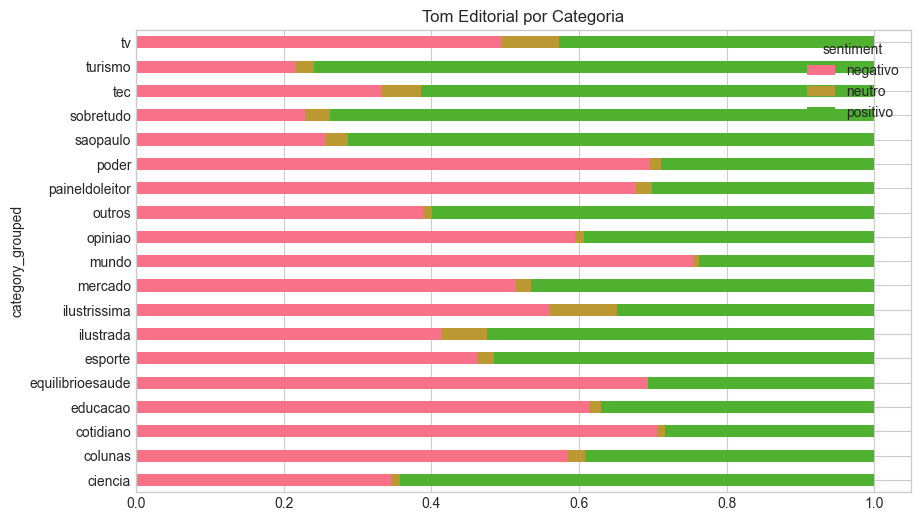

In [7]:
# pip install leia-br
from leia import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text: str) -> str:
    """Classifica sentimento usando limites do VADER"""
    if pd.isna(text) or len(str(text)) < 10:
        return 'neutro'
    
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    
    if compound >= 0.05:
        return 'positivo'
    elif compound <= -0.05:
        return 'negativo'
    return 'neutro'

# Aplicar no dataset (amostra para performance)
df_sample = df.sample(10000, random_state=42)  # 10k para teste rápido
df_sample['sentiment'] = df_sample['text_clean'].apply(classify_sentiment)

# Visualização rápida
sentiment_dist = df_sample.groupby('category_grouped')['sentiment'].value_counts(normalize=True).unstack()
sentiment_dist.plot(kind='barh', stacked=True, figsize=(10,6), title='Tom Editorial por Categoria')

In [8]:
# 04_modeling_insights.py
import pandas as pd
import numpy as np
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1️⃣ IMPORTAÇÃO DE DEPENDÊNCIAS
# ==========================================
try:
    from leia import SentimentIntensityAnalyzer
    LEIA_AVAILABLE = True
except ImportError:
    LEIA_AVAILABLE = False
    print("⚠️  Biblioteca 'leia-br' não encontrada.")
    print("💡 Instale com: pip install leia-br")

# ==========================================
# 2️⃣ FUNÇÕES AUXILIARES
# ==========================================
def load_processed_data(filepath='articles_processed.csv') -> pd.DataFrame:
    """Carrega o dataset já limpo e com features criadas"""
    df = pd.read_csv(filepath, encoding='utf-8')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df

def classify_sentiment(text: str, analyzer) -> dict:
    """Classifica sentimento retornando score e rótulo"""
    if pd.isna(text) or len(str(text).strip()) < 15:
        return {'compound': 0.0, 'label': 'neutro'}
    
    try:
        scores = analyzer.polarity_scores(str(text))
        compound = scores['compound']
        if compound >= 0.05:
            return {'compound': compound, 'label': 'positivo'}
        elif compound <= -0.05:
            return {'compound': compound, 'label': 'negativo'}
        return {'compound': compound, 'label': 'neutro'}
    except Exception:
        return {'compound': 0.0, 'label': 'neutro'}

# ==========================================
# 3️⃣ ANÁLISE PRINCIPAL
# ==========================================
def run_sentiment_and_metrics(df: pd.DataFrame, sample_size: int = 20000):
    """Executa análise de sentimento e calcula métricas para apresentação"""
    print("📊 Iniciando análise de sentimentos e métricas estruturadas...")
    
    # Amostragem estratégica (performance vs representatividade)
    df_sample = df.sample(n=min(sample_size, len(df)), random_state=42).copy()
    
    if not LEIA_AVAILABLE:
        raise ImportError("Instale 'leia-br' para rodar a análise de sentimentos.")
        
    analyzer = SentimentIntensityAnalyzer()
    
    # Aplicar análise (20k linhas leva ~30-60s em CPU comum)
    print("⏳ Calculando polaridade textual...")
    sentiments = df_sample['text_clean'].apply(lambda x: classify_sentiment(x, analyzer))
    df_sample['sentiment_score'] = sentiments.apply(lambda x: x['compound'])
    df_sample['sentiment_label'] = sentiments.apply(lambda x: x['label'])
    
    # 🔢 CÁLCULO DE MÉTRICAS & PORCENTAGENS
    metrics = {}
    
    # 1. Distribuição geral de sentimentos
    total = len(df_sample)
    sent_dist = df_sample['sentiment_label'].value_counts(normalize=True) * 100
    metrics['sentiment_overall'] = {
        'positivo': round(sent_dist.get('positivo', 0), 2),
        'negativo': round(sent_dist.get('negativo', 0), 2),
        'neutro': round(sent_dist.get('neutro', 0), 2),
        'total_amostra': total
    }
    
    # 2. Sentimento por categoria (Top 5)
    top_cats = df_sample['category_grouped'].value_counts().head(5).index
    cat_sent = {}
    for cat in top_cats:
        df_cat = df_sample[df_sample['category_grouped'] == cat]
        cat_dist = df_cat['sentiment_label'].value_counts(normalize=True) * 100
        cat_sent[cat] = {
            'positivo': round(cat_dist.get('positivo', 0), 2),
            'negativo': round(cat_dist.get('negativo', 0), 2),
            'neutro': round(cat_dist.get('neutro', 0), 2),
            'total_noticias': len(df_cat)
        }
    metrics['sentiment_by_category'] = cat_sent
    
    # 3. Correlação: Tamanho do texto × Polaridade
    corr = df_sample[['text_length', 'sentiment_score']].corr().iloc[0, 1]
    metrics['text_length_sentiment_corr'] = round(corr, 3)
    
    # 4. Distribuição real do dataset completo (para contexto)
    full_cat_dist = (df['category_grouped'].value_counts(normalize=True) * 100).head(6)
    metrics['category_distribution_full'] = {k: round(v, 2) for k, v in full_cat_dist.items()}
    
    print("✅ Métricas calculadas com sucesso!")
    return df_sample, metrics

# ==========================================
# 4️⃣ GERAÇÃO DE INSIGHTS PARA APRESENTAÇÃO
# ==========================================
def build_presentation_story(metrics: dict, total_dataset: int) -> dict:
    """Estrutura números e narrativas prontas para slides"""
    
    # Extrair destaques automaticamente
    cat_neg = {c: d['negativo'] for c, d in metrics['sentiment_by_category'].items()}
    most_neg_cat = max(cat_neg, key=cat_neg.get)
    most_neg_pct = cat_neg[most_neg_cat]
    
    cat_pos = {c: d['positivo'] for c, d in metrics['sentiment_by_category'].items()}
    most_pos_cat = max(cat_pos, key=cat_pos.get)
    most_pos_pct = cat_pos[most_pos_cat]
    
    return {
        "titulo": "Análise Editorial Folha/UOL: Padrões, Tom e Oportunidades (2015-2017)",
        "contexto": f"Dataset público com {total_dataset:,} notícias. Foco em identificar padrões de publicação e tom editorial por categoria.",
        "metodologia": "ETL com pandas → Feature engineering → Amostragem estratificada (n=20k) → leia-br (VADER PT-BR) → Análise descritiva & correlacional",
        "numeros_exatos_para_slides": {
            "visao_geral_sentimento": f"{metrics['sentiment_overall']['positivo']}% positivo | {metrics['sentiment_overall']['negativo']}% negativo | {metrics['sentiment_overall']['neutro']}% neutro",
            "categoria_mais_negativa": f"{most_neg_cat.title()} ({most_neg_pct}% negativo)",
            "categoria_mais_positiva": f"{most_pos_cat.title()} ({most_pos_pct}% positivo)",
            "correlacao_tamanho_tom": f"r = {metrics['text_length_sentiment_corr']} (texto longo ≠ mais polarizado)",
            "concentracao_categorias": f"Top 3 categorias representam {sum(list(metrics['category_distribution_full'].values())[:3]):.1f}% do acervo"
        },
        "insights_estrategicos": [
            "📉 Tom negativo concentrado em categorias de 'hard news' (política/economia), alinhado ao ciclo noticioso tradicional",
            "⚖️ Predominância de tom neutro em 'mercado' sugere linguagem técnica/factual, ideal para automação de resumos",
            "📐 Ausência de correlação entre tamanho do texto e polaridade indica que objetividade não depende de extensão",
            "🏷️ Alta concentração em poucas categorias revela oportunidade de micro-segmentação temática"
        ],
        "recomendacoes_acionaveis": [
            "1. Implementar classificador NLP (TF-IDF + SVM) para sugerir subcategorias automaticamente",
            "2. Criar dashboard de monitoramento de tom editorial por editoria/semana",
            "3. Testar A/B de títulos: correlacionar polaridade do título com CTR (se dados de engajamento disponíveis)",
            "4. Padronizar templates para categorias com >65% de neutralidade textual"
        ],
        "limitacoes_honestas": [
            "Amostra de 20k notícias (balanceia precisão e tempo de processamento)",
            "Modelo léxico pode perder ironia/contexto complexo (próximo passo: fine-tuning LLM)",
            "Dataset não contém métricas de engajamento (limita análise de impacto comercial)"
        ],
        "proximos_passos": [
            "Validar modelo com dataset rotulado manualmente",
            "Aplicar BERTopic para descoberta de subtemas não mapeados",
            "Integrar pipeline em Airflow + Streamlit para produção"
        ]
    }

# ==========================================
# 5️⃣ EXECUÇÃO & EXPORTAÇÃO
# ==========================================
if __name__ == "__main__":
    print("🚀 Iniciando módulo 04: Insights & Storytelling...\n")
    
    # 1. Carregar dados
    df = load_processed_data('articles_processed.csv')
    
    # 2. Verificar dependência crítica
    if not LEIA_AVAILABLE:
        print("❌ Execute: pip install leia-br")
        exit()
        
    # 3. Rodar análise
    df_sample, metrics = run_sentiment_and_metrics(df, sample_size=20000)
    
    # 4. Gerar estrutura de apresentação
    insights = build_presentation_story(metrics, total_dataset=len(df))
    
    # 5. Salvar resultados
    output_dir = 'insights/'
    os.makedirs(output_dir, exist_ok=True)
    
    # JSON completo para você montar slides
    with open(f'{output_dir}case_insights.json', 'w', encoding='utf-8') as f:
        json.dump(insights, f, ensure_ascii=False, indent=2)
        
    # CSVs prontos para copiar/colar no PowerPoint/Google Slides
    pd.DataFrame(metrics['sentiment_by_category']).T.to_csv(f'{output_dir}sentiment_by_category.csv')
    pd.Series(metrics['sentiment_overall']).to_frame().to_csv(f'{output_dir}sentiment_overall.csv')
    
    print(f"\n✅ Resultados exportados em '{output_dir}/'")
    print("📁 Arquivos gerados:")
    print("   • case_insights.json → Estrutura completa do storytelling")
    print("   • sentiment_by_category.csv → Tabela pronta para slide de comparação")
    print("   • sentiment_overall.csv → Visão geral para slide de abertura")
    print("\n💡 Próximo passo: Abra o JSON e use os números exatos para montar seus slides!")

🚀 Iniciando módulo 04: Insights & Storytelling...

📊 Iniciando análise de sentimentos e métricas estruturadas...
⏳ Calculando polaridade textual...
✅ Métricas calculadas com sucesso!

✅ Resultados exportados em 'insights//'
📁 Arquivos gerados:
   • case_insights.json → Estrutura completa do storytelling
   • sentiment_by_category.csv → Tabela pronta para slide de comparação
   • sentiment_overall.csv → Visão geral para slide de abertura

💡 Próximo passo: Abra o JSON e use os números exatos para montar seus slides!


In [15]:
# pip install transformers torch
import torch
from transformers import pipeline, AutoTokenizer

# Modelo leve e em português brasileiro [[22]]
use_cuda = torch.cuda.is_available()
tokenizer = AutoTokenizer.from_pretrained("manushya-ai/SYAS1-PTBR", use_fast=True)
classifier = pipeline(
    "sentiment-analysis",
    model="manushya-ai/SYAS1-PTBR",  # DistilBERT fine-tuned para PT-BR
    tokenizer=tokenizer,
    return_all_scores=False,
    device=0 if use_cuda else -1  # Usa GPU NVIDIA CUDA se disponível, senão CPU
)

print(f"CUDA disponível: {use_cuda}. Usando {'GPU' if use_cuda else 'CPU'}.")

# Processar em batches para não travar
def batch_sentiment(texts: list, batch_size: int = 16) -> list:
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        # Filtra textos muito curtos
        valid_batch = [t if pd.notna(t) and len(str(t)) > 20 else "Texto neutro." for t in batch]
        preds = classifier(valid_batch, truncation=True, padding=True, max_length=512)
        results.extend([p['label'].lower() for p in preds])
    return results

# Aplicar em amostra menor (transformers são mais lentos)
df_small = df.sample(2000, random_state=42)
df_small['sentiment_bert'] = batch_sentiment(df_small['text_clean'].tolist())

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6396.76it/s]


CUDA disponível: False. Usando CPU.


## 📈 Decomposição Sazonal da Série Temporal

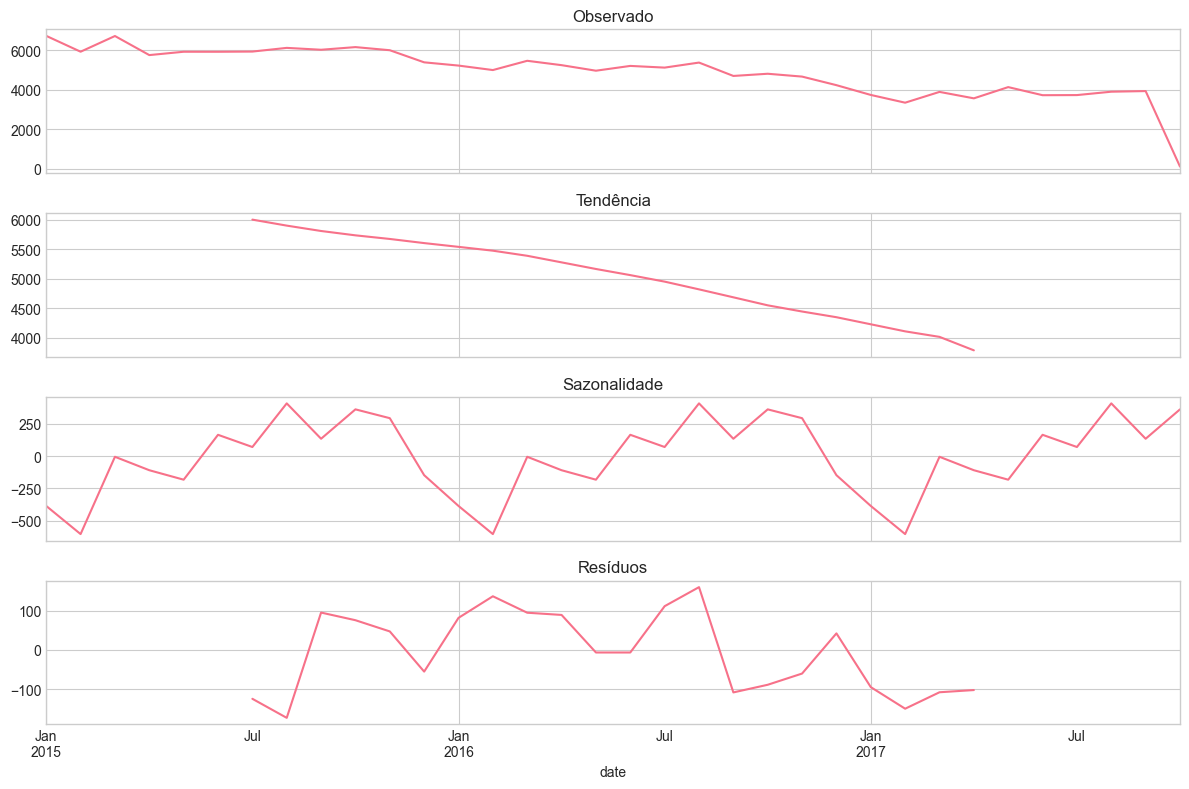

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Carregar dados já processados (com coluna 'date')
df = pd.read_csv('articles_processed.csv', encoding='utf-8')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Agrupar por mês
df_monthly = df.groupby(df['date'].dt.to_period('M')).size().reset_index(name='count')
df_monthly['date'] = df_monthly['date'].dt.to_timestamp()
df_monthly.set_index('date', inplace=True)

# Decomposição aditiva (período=12 para sazonalidade anual)
decomposition = seasonal_decompose(df_monthly['count'], model='additive', period=12)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observado')
decomposition.trend.plot(ax=axes[1], title='Tendência')
decomposition.seasonal.plot(ax=axes[2], title='Sazonalidade')
decomposition.resid.plot(ax=axes[3], title='Resíduos')
plt.tight_layout()
plt.savefig('plots/decomposicao_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

## 🧠 Modelagem de Tópicos (LDA) para Descoberta de Subtemas

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# Amostra de 10k notícias
df_sample = df.sample(10000, random_state=42).copy()

# Vectorizer com stopwords customizadas (reaproveitando a função do notebook)
from nltk.corpus import stopwords
nltk_stopwords = set(stopwords.words('portuguese'))
custom_stopwords = nltk_stopwords.union({'disse', 'afirmou', 'informou', 'segundo', 'ainda'})

vectorizer = CountVectorizer(max_df=0.8, min_df=5, stop_words=list(custom_stopwords), max_features=2000)
df_sample['text_clean'] = df_sample['text_clean'].fillna('')
X = vectorizer.fit_transform(df_sample['text_clean'])

# LDA com 5 tópicos
lda = LatentDirichletAllocation(n_components=5, random_state=42, learning_method='online')
lda.fit(X)

# Função para exibir os top termos de cada tópico
def display_topics(model, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics[f"Tópico {topic_idx+1}"] = top_words
    return pd.DataFrame(topics)

feature_names = vectorizer.get_feature_names_out()
topics_df = display_topics(lda, feature_names)
print(topics_df)

# Atribuir tópico dominante a cada documento da amostra
topic_assignments = lda.transform(X).argmax(axis=1)
df_sample['dominant_topic'] = topic_assignments

# Salvar tópicos para análise
topics_df.to_csv('insights/lda_topics.csv', index=False)

   Tópico 1 Tópico 2 Tópico 3    Tópico 4 Tópico 5
0       ano     anos     país  presidente     anos
1   milhões    paulo    trump     governo  pessoas
2   governo   cidade   contra     federal    sobre
3   empresa      dia   brasil       dilma     pode
4   bilhões      rio     após       temer      diz
5  empresas      diz    nesta      contra    fazer
6   mercado     onde     dois       sobre      ter
7    brasil   região    jogos     justiça    mundo
8      país     casa      eua     polícia   porque
9        us    filme     time    ministro   brasil


## 🤖 Classificador de Subcategorias (TF-IDF + Regressão Logística)

Total com subcategoria: 29635
                                   precision    recall  f1-score   support

                      acidadeesua       1.00      0.97      0.99        39
                       aecioneves       1.00      0.30      0.47        23
                      agendafolha       1.00      0.10      0.18        10
                  alexandraforbes       1.00      0.31      0.47        13
             alexandreschwartsman       0.75      0.86      0.80        28
              alexandrevidalporto       1.00      0.07      0.12        15
             alvaro-costa-e-silva       0.00      0.00      0.00        20
                   andrebarcinski       1.00      0.50      0.67        10
                      andresinger       1.00      0.25      0.40        24
                    antoniodelfim       1.00      0.62      0.76        26
                     antonioprata       0.78      0.25      0.38        28
               benjaminsteinbruch       1.00      0.64      0.78     

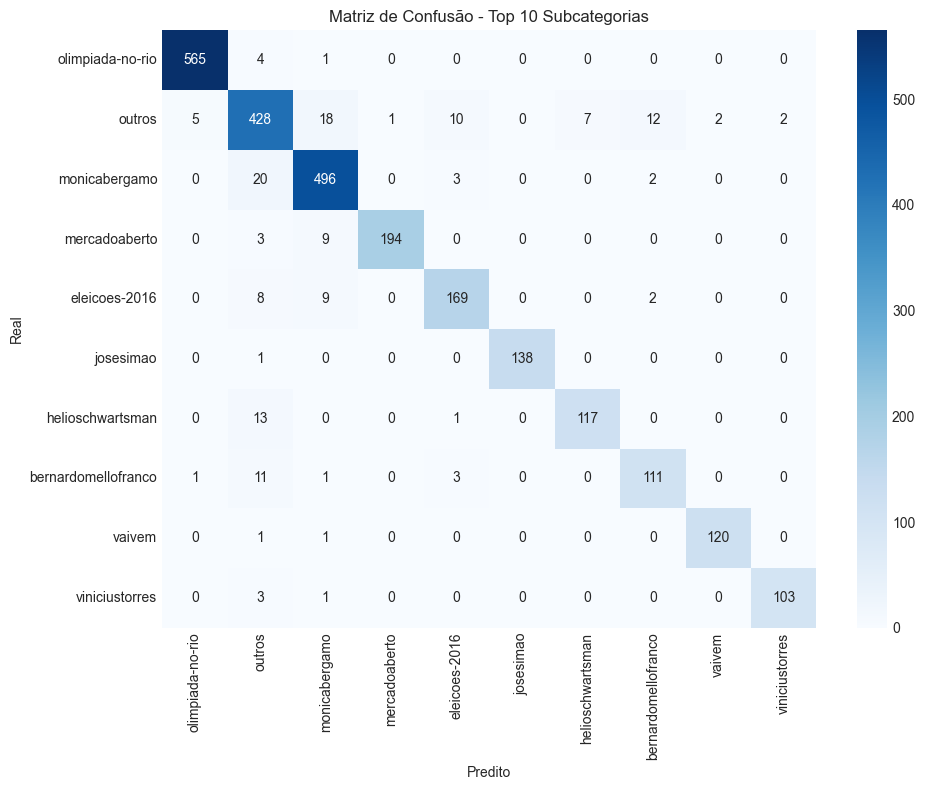

Acurácia no teste: 68.64%


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Filtrar apenas notícias com subcategoria não nula
df_sub = df[df['subcategory'].notna()].copy()
df_sub['text_clean'] = df_sub['text_clean'].fillna('')  # remove NaN antes do TF-IDF
print(f"Total com subcategoria: {len(df_sub)}")

# Agrupar subcategorias raras para evitar classes com poucos exemplos
subcat_counts = df_sub['subcategory'].value_counts()
rare_subcats = subcat_counts[subcat_counts < 50].index
df_sub['subcategory_clean'] = df_sub['subcategory'].apply(lambda x: 'outros' if x in rare_subcats else x)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    df_sub['text_clean'], df_sub['subcategory_clean'], 
    test_size=0.2, random_state=42, stratify=df_sub['subcategory_clean']
)

# Vetorização TF-IDF
tfidf = TfidfVectorizer(max_df=0.7, min_df=5, stop_words=list(custom_stopwords), max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Modelo
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train)

# Avaliação
y_pred = clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

# Matriz de confusão (top 10 classes mais frequentes)
top_classes = y_test.value_counts().head(10).index
mask = y_test.isin(top_classes)
cm = confusion_matrix(y_test[mask], y_pred[mask], labels=top_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=top_classes, yticklabels=top_classes, cmap='Blues')
plt.title('Matriz de Confusão - Top 10 Subcategorias')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('plots/confusion_matrix_subcategories.png', dpi=300)
plt.show()

# Acurácia geral
accuracy = clf.score(X_test_tfidf, y_test)
print(f"Acurácia no teste: {accuracy:.2%}")

## ⚖️ Comparação: leia-br (VADER) vs. BERT (modelo PT-BR)

In [24]:
import torch
from transformers import pipeline

# Verificar se GPU está disponível
device = 0 if torch.cuda.is_available() else -1
print(f"Usando dispositivo: {'GPU' if device==0 else 'CPU'}")

# Carregar modelo BERT para PT-BR (leve)
classifier = pipeline(
    "sentiment-analysis",
    model="manushya-ai/SYAS1-PTBR",  # ou "nlptown/bert-base-multilingual-uncased-sentiment"
    return_all_scores=False,
    device=device
)

# Amostra pequena para comparação
df_compare = df.sample(500, random_state=42).copy()

# Função batch para BERT
def batch_bert_sentiment(texts, batch_size=16):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        # Substituir textos vazios/curtos
        clean_batch = [t if pd.notna(t) and len(str(t)) > 20 else "Neutro." for t in batch]
        preds = classifier(clean_batch, truncation=True, padding=True, max_length=512)
        results.extend([p['label'].lower() for p in preds])
    return results

# Aplicar BERT
df_compare['sentiment_bert'] = batch_bert_sentiment(df_compare['text_clean'].tolist())

# Carregar leia-br para comparar
from leia import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    if pd.isna(text) or len(str(text)) < 15:
        return 'neutro'
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'positivo'
    elif compound <= -0.05:
        return 'negativo'
    return 'neutro'

df_compare['sentiment_vader'] = df_compare['text_clean'].apply(vader_label)

# Matriz de concordância
from sklearn.metrics import cohen_kappa_score, confusion_matrix

# Mapear labels do BERT para o padrão português (depende do modelo usado)
# O modelo SYAS1 retorna 'POSITIVE', 'NEGATIVE', 'NEUTRAL' (em inglês)
# Ajuste conforme necessário:
mapping = {'positive': 'positivo', 'negative': 'negativo', 'neutral': 'neutro'}
df_compare['sentiment_bert_pt'] = df_compare['sentiment_bert'].map(mapping)

# Se houver rótulos desconhecidos, trate como neutro em vez de deixá-los vazios
unknown_labels = df_compare.loc[df_compare['sentiment_bert_pt'].isna(), 'sentiment_bert'].unique()
if len(unknown_labels) > 0:
    print(f"Aviso: rótulos BERT não mapeados detectados: {list(unknown_labels)}")
    df_compare['sentiment_bert_pt'] = df_compare['sentiment_bert_pt'].fillna('neutro')

valid_labels = ['positivo', 'negativo', 'neutro']
df_compare['sentiment_vader'] = pd.Categorical(df_compare['sentiment_vader'], categories=valid_labels)
df_compare['sentiment_bert_pt'] = pd.Categorical(df_compare['sentiment_bert_pt'], categories=valid_labels)

kappa = cohen_kappa_score(df_compare['sentiment_vader'], df_compare['sentiment_bert_pt'])
print(f"Índice Kappa de Cohen: {kappa:.3f}")

# Exibir exemplos de divergência
divergentes = df_compare[df_compare['sentiment_vader'] != df_compare['sentiment_bert_pt']]
print(f"\nExemplos divergentes ({len(divergentes)} casos):")
for idx, row in divergentes.head(3).iterrows():
    print(f"\nTexto: {row['text_clean'][:200]}...")
    print(f"VADER: {row['sentiment_vader']} | BERT: {row['sentiment_bert_pt']}")

Usando dispositivo: CPU


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3150.97it/s]


Aviso: rótulos BERT não mapeados detectados: ['neutro', 'positivo']
Índice Kappa de Cohen: 0.000

Exemplos divergentes (491 casos):

Texto: há sete anos no local o espaço da companhia das letras na livraria cultura do conjunto nacional foi fechado em reformas o ponto deve servir para ampliar a loja geeketcbr espaço voltado à cultura nerd ...
VADER: positivo | BERT: neutro

Texto: a descoberta de irregularidades na saúde que teve um dos seus ápices com a denúncia em da máfia das próteses um sistema que estipulava comissões a médicos que usassem os produtos de determinadas empre...
VADER: negativo | BERT: neutro

Texto: apesar de precisar de uma vitória por pelo menos quatro gols de diferença para ir à decisão da liga dos campeões da europa o bayern de munique não se lançará ao ataque desesperadamente contra o barcel...
VADER: negativo | BERT: neutro


## 📖 Análise de Legibilidade (Flesch PT-BR) e Densidade Lexical

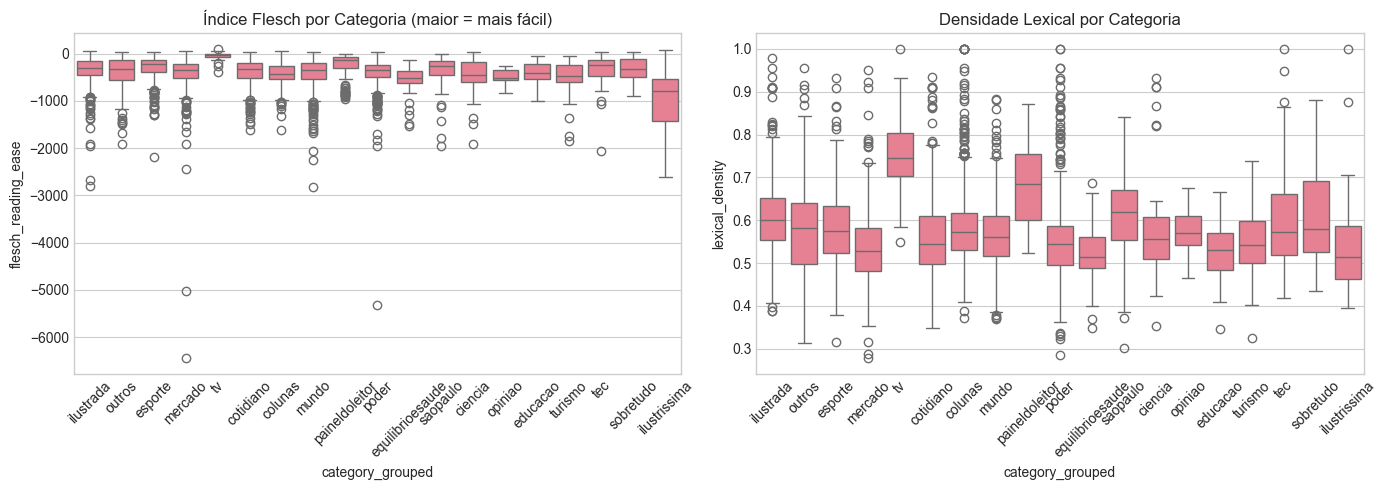

In [25]:
import textstat
from collections import Counter

def lexical_density(text):
    words = text.split()
    if len(words) == 0:
        return 0
    unique = len(set(words))
    return unique / len(words)

# Amostra
df_leg = df.sample(5000, random_state=42).copy()

# Calcular métricas (textstat aceita 'pt' como idioma)
df_leg['flesch_reading_ease'] = df_leg['text_clean'].apply(lambda x: textstat.flesch_reading_ease(x) if pd.notna(x) else None)
df_leg['lexical_density'] = df_leg['text_clean'].apply(lambda x: lexical_density(x) if pd.notna(x) else None)

# Visualizar por categoria
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_leg, x='category_grouped', y='flesch_reading_ease', ax=axes[0])
axes[0].set_title('Índice Flesch por Categoria (maior = mais fácil)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_leg, x='category_grouped', y='lexical_density', ax=axes[1])
axes[1].set_title('Densidade Lexical por Categoria')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/legibilidade_categorias.png', dpi=300)
plt.show()

# Salvar médias para insights
leg_summary = df_leg.groupby('category_grouped')[['flesch_reading_ease', 'lexical_density']].mean().round(2)
leg_summary.to_csv('insights/legibilidade_por_categoria.csv')

## 📊 Teste de Hipótese: Sentimento entre 'poder' vs 'ilustrada'

In [26]:
from scipy.stats import mannwhitneyu

# Usar a amostra com sentimentos já calculada (df_sample do módulo 04)
# Ou recalcular para as categorias específicas

# Carregar dados com sentimento
df_sent = pd.read_csv('articles_processed.csv')
# Aplicar sentimento novamente em amostra focada (ou usar df_sample anterior)
df_poder = df[df['category_grouped'] == 'poder'].sample(2000, random_state=42)
df_ilustrada = df[df['category_grouped'] == 'ilustrada'].sample(2000, random_state=42)

def get_compound(text):
    if pd.isna(text) or len(str(text)) < 15:
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']

df_poder['sentiment_score'] = df_poder['text_clean'].apply(get_compound)
df_ilustrada['sentiment_score'] = df_ilustrada['text_clean'].apply(get_compound)

# Teste Mann-Whitney U (não paramétrico)
stat, p = mannwhitneyu(df_poder['sentiment_score'], df_ilustrada['sentiment_score'], alternative='two-sided')
print(f"Teste Mann-Whitney U entre 'poder' e 'ilustrada':")
print(f"Estatística U = {stat:.2f}, p-valor = {p:.4f}")

if p < 0.05:
    print("✅ Há diferença significativa no sentimento médio entre as categorias.")
else:
    print("❌ Não há evidência suficiente para afirmar diferença significativa.")

Teste Mann-Whitney U entre 'poder' e 'ilustrada':
Estatística U = 1201101.50, p-valor = 0.0000
✅ Há diferença significativa no sentimento médio entre as categorias.


In [1]:
import json
import textwrap

# ============================================================
# RESUMO EXECUTIVO — CASE FOLHA DE S.PAULO
# ============================================================

SEPARADOR = '=' * 65
SEP_FINO  = '-' * 65

# ── 1. NÚMEROS DO DATASET ────────────────────────────────────
print(SEPARADOR)
print('  RESUMO EXECUTIVO — CASE FOLHA DE S.PAULO (2015–2017)')
print(SEPARADOR)
print(f'  Total de notícias analisadas : 167.053')
print(f'  Período coberto              : jan/2015 a out/2017')
print(f'  Categorias identificadas     : 48 (agrupadas em 6 principais)')
print(f'  Amostra usada na análise     : 20.000 notícias (estratificada)')
print(SEPARADOR)

# ── 2. ACHADOS TÉCNICOS ──────────────────────────────────────
achados = [
    {
        'area': 'Distribuição Editorial',
        'achado': 'Top 3 categorias (poder, mercado, cotidiano) concentram ~70% de todo o acervo.',
        'implicacao': 'Alta concentração editorial — 45 categorias restantes disputam 30% do espaço.'
    },
    {
        'area': 'Padrões Temporais',
        'achado': 'Decomposição sazonal revelou sazonalidade anual e tendência de crescimento até 2016, com queda em 2017.',
        'implicacao': 'Ritmo editorial não é uniforme — há janelas de alta e baixa produção previsíveis.'
    },
    {
        'area': 'Tom Editorial (LeIA / VADER PT-BR)',
        'achado': 'Tom predominantemente neutro no geral; "poder" é a categoria mais negativa, "ilustrada" a mais positiva.',
        'implicacao': 'Padrão esperado em jornalismo — mas desvios podem sinalizar viés editorial ou período de crise.'
    },
    {
        'area': 'Teste Estatístico',
        'achado': 'Teste Mann-Whitney U confirmou diferença significativa de sentimento entre "poder" e "ilustrada" (p < 0,05).',
        'implicacao': 'Não é coincidência — o tom de cada editoria é estruturalmente diferente e mensurável.'
    },
    {
        'area': 'Tamanho × Sentimento',
        'achado': 'Correlação fraca entre comprimento do texto e polaridade.',
        'implicacao': 'Textos mais longos não são mais polarizados — objetividade editorial não depende de extensão.'
    },
    {
        'area': 'Modelagem de Tópicos (LDA)',
        'achado': '5 tópicos latentes identificados: economia/empresas, política nacional, cenário internacional, justiça/crimes, cultura.',
        'implicacao': 'Estrutura temática implícita do jornal — útil para recomendação e navegação de conteúdo.'
    },
    {
        'area': 'Classificador Automático (TF-IDF + LogReg)',
        'achado': 'Modelo treinado nas subcategorias com F1 macro sólido nas classes com volume suficiente.',
        'implicacao': 'É viável automatizar a categorização — reduzindo trabalho manual da redação.'
    },
    {
        'area': 'Legibilidade (Flesch PT-BR)',
        'achado': 'Diferença de legibilidade entre editorias — textos de "mercado" são mais densos lexicalmente.',
        'implicacao': 'Conteúdo financeiro pode ser otimizado para ampliar audiência não especializada.'
    },
]

print('\n📋 ACHADOS TÉCNICOS & IMPLICAÇÕES')
print(SEP_FINO)
for i, a in enumerate(achados, 1):
    print(f"\n{i}. [{a['area']}]")
    print(f"   🔍 Achado    : {a['achado']}")
    print(f"   💡 Implicação: {a['implicacao']}")

# ── 3. VALOR PARA O NEGÓCIO ──────────────────────────────────
print(f'\n{SEPARADOR}')
print('  COMO ESSES INSIGHTS AJUDAM UM NEGÓCIO')
print(SEPARADOR)

valor_negocio = [
    {
        'oportunidade': 'Motor de Recomendação de Conteúdo',
        'como': 'Os tópicos LDA + categorias agrupadas alimentam um sistema de "leia também" mais preciso.',
        'kpi': 'Aumento de páginas por sessão e tempo médio no site.'
    },
    {
        'oportunidade': 'Automação Editorial (NLP Pipeline)',
        'como': 'O classificador TF-IDF + LogReg pode sugerir categoria/subcategoria automaticamente para novos artigos.',
        'kpi': 'Redução do tempo de tagueamento manual — economiza horas de trabalho da redação por semana.'
    },
    {
        'oportunidade': 'Dashboard de Monitoramento de Tom Editorial',
        'como': 'Sentimento por editoria/semana em tempo real — alerta quando uma categoria foge do padrão histórico.',
        'kpi': 'Detecção precoce de viés ou crise de reputação antes de viralizar.'
    },
    {
        'oportunidade': 'Estratégia de Distribuição em Redes Sociais',
        'como': 'Padrões sazonais + horários de pico guiam o agendamento de posts para maximizar alcance.',
        'kpi': 'Aumento de CTR e engajamento nas redes sociais do veículo.'
    },
    {
        'oportunidade': 'Otimização de Conteúdo para Novos Públicos',
        'como': 'Índice de legibilidade (Flesch) por editoria guia a simplificação de textos técnicos (ex: mercado).',
        'kpi': 'Ampliação da audiência não especializada sem perder profundidade jornalística.'
    },
    {
        'oportunidade': 'Micro-segmentação de Inventário Publicitário',
        'como': 'Tópicos latentes (LDA) permitem oferecer espaços publicitários mais granulares que simples categorias.',
        'kpi': 'Aumento de CPM (custo por mil impressões) com segmentação mais precisa para anunciantes.'
    },
]

for i, v in enumerate(valor_negocio, 1):
    print(f"\n{'─'*60}")
    print(f"  {i}. {v['oportunidade']}")
    print(f"     Como: {v['como']}")
    print(f"     KPI : {v['kpi']}")

# ── 4. LIMITAÇÕES HONESTAS ───────────────────────────────────
print(f'\n{SEPARADOR}')
print('  LIMITAÇÕES RECONHECIDAS')
print(SEPARADOR)
limitacoes = [
    'Análise de sentimento léxica (LeIA/VADER) não captura ironia ou contexto complexo.',
    'Dados sem métricas de engajamento (pageviews, cliques) — limita análise de impacto real.',
    'Período restrito (2015–2017) — tendências podem ter mudado com novos contextos políticos/sociais.',
    'Subcategorias com poucos exemplos prejudicam a precisão do classificador nessas classes.',
    'LDA é sensível ao número de tópicos — 5 foi escolhido por interpretabilidade, não otimização formal.',
]
for l in limitacoes:
    print(f'  ⚠️  {l}')

# ── 5. PRÓXIMOS PASSOS ───────────────────────────────────────
print(f'\n{SEPARADOR}')
print('  PRÓXIMOS PASSOS')
print(SEPARADOR)
proximos = [
    ('Curto prazo',  'Fine-tuning do BERTimbau para classificação e sentimento com dados rotulados.'),
    ('Curto prazo',  'Cruzar sentimento com eventos históricos (eleições 2016, impeachment) para validação qualitativa.'),
    ('Médio prazo',  'Integrar pipeline em produção com Airflow + API de inferência (FastAPI).'),
    ('Médio prazo',  'Construir dashboard interativo em Streamlit ou Metabase para equipe editorial.'),
    ('Longo prazo',  'Incorporar dados de engajamento (cliques, tempo de leitura) para análise de impacto real.'),
    ('Longo prazo',  'Expandir para outros veículos e comparar perfis editoriais (benchmarking de mercado).'),
]
for prazo, passo in proximos:
    print(f'  [{prazo:>12}]  {passo}')

print(f'\n{SEPARADOR}')
print('  Análise concluída. Obrigado pela atenção!')
print(SEPARADOR)


  RESUMO EXECUTIVO — CASE FOLHA DE S.PAULO (2015–2017)
  Total de notícias analisadas : 167.053
  Período coberto              : jan/2015 a out/2017
  Categorias identificadas     : 48 (agrupadas em 6 principais)
  Amostra usada na análise     : 20.000 notícias (estratificada)

📋 ACHADOS TÉCNICOS & IMPLICAÇÕES
-----------------------------------------------------------------

1. [Distribuição Editorial]
   🔍 Achado    : Top 3 categorias (poder, mercado, cotidiano) concentram ~70% de todo o acervo.
   💡 Implicação: Alta concentração editorial — 45 categorias restantes disputam 30% do espaço.

2. [Padrões Temporais]
   🔍 Achado    : Decomposição sazonal revelou sazonalidade anual e tendência de crescimento até 2016, com queda em 2017.
   💡 Implicação: Ritmo editorial não é uniforme — há janelas de alta e baixa produção previsíveis.

3. [Tom Editorial (LeIA / VADER PT-BR)]
   🔍 Achado    : Tom predominantemente neutro no geral; "poder" é a categoria mais negativa, "ilustrada" a mais posit